In [308]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [332]:
words = open("../etc/names.txt", "r").read().splitlines()
words[:8]
len(words)

32033

In [310]:
chars = sorted(list(set(''.join(words))))
stoi = {s : i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [311]:
block_size = 3
X, Y = [], []

for w in words:
	# print(w)
	context = [0] * block_size
	for ch in w + '.':
		ix = stoi[ch]
		X.append(context)
		Y.append(ix)
		# print(''.join(itos[i] for i in context), '----->', itos[ix])
		context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [312]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [313]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        ...,
        [26, 26, 25],
        [26, 25, 26],
        [25, 26, 24]])

In [314]:
C = torch.randn((27, 2))

In [315]:
C

tensor([[-0.6519, -1.2642],
        [ 0.6385,  1.5596],
        [-2.1536,  1.7872],
        [ 1.0719, -0.6150],
        [-0.7532, -0.9749],
        [-0.2357,  1.3073],
        [-0.0541, -1.4008],
        [ 0.7630,  1.0266],
        [-0.4086, -1.2311],
        [-0.1454,  0.2822],
        [-0.0119,  0.6565],
        [-0.9170, -0.5942],
        [-1.7346, -0.0103],
        [-0.9488,  0.0741],
        [-0.5065, -0.3057],
        [-3.0219,  0.3904],
        [ 0.6103,  1.4355],
        [-1.9063, -0.3176],
        [ 1.2623, -0.5501],
        [ 0.9369, -1.0211],
        [ 0.0418,  0.2260],
        [ 1.9062,  0.0915],
        [-0.9603,  0.0122],
        [ 0.3410, -1.5243],
        [ 0.5779, -0.1969],
        [-0.4409, -1.2076],
        [-1.8873, -1.1544]])

In [316]:
C[0]

tensor([-0.6519, -1.2642])

In [317]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-0.2357,  1.3073])

In [318]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [319]:
w1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [320]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([228146, 6])

In [321]:
torch.cat(torch.unbind(emb, 1), 1).shape ## inefficient cause no way to manipulate tensors, creates new stufff in mem

torch.Size([228146, 6])

In [322]:
emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)

RuntimeError: shape '[32, 6]' is invalid for input of size 1368876

In [ ]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1) == torch.cat(torch.unbind(emb, 1), 1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [ ]:
# h = emb.view(emb.shape[0], 6) @ w1 + b1
h = torch.tanh(emb.view(-1, 6) @ w1 + b1)

In [ ]:
h

tensor([[ 0.9996,  0.3866,  0.9984,  ...,  0.7688, -0.4934,  0.9982],
        [ 0.9991,  0.5431, -0.6459,  ...,  0.9805, -0.9795, -0.7560],
        [ 0.4881,  0.9963,  0.9550,  ..., -0.9407, -0.8859,  0.9999],
        ...,
        [-0.8903,  0.9927,  0.9511,  ...,  0.7936,  0.9496,  0.7221],
        [-0.5955,  0.9205,  0.7335,  ...,  0.7655, -0.8200,  0.7921],
        [-0.8870,  0.9394,  0.9912,  ...,  0.1791,  0.3973,  0.9588]])

In [ ]:
w2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [ ]:
logits = h @ w2 + b2
logits.shape

torch.Size([32, 27])

In [ ]:
counts = logits.exp()

In [ ]:
probs = counts / counts.sum(1, keepdims=True) # all rows add to one

In [ ]:
nll = -probs[torch.arange(32), Y].log().mean()
nll

tensor(15.7289)

In [ ]:
# ======= putting it all together ========

In [ ]:
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [324]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g, requires_grad=True)
w1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, w1, b1, w2, b2]

In [325]:
sum(p.nelement() for p in parameters)

4881

In [299]:
for p in parameters:
	p.requires_grad = True

In [300]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [303]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [306]:
lri = []
lossi = []
for i in range(10000):
	ix = torch.randint(0, Xtr.shape[0], (32,))

	#forward pass
	emb = C[Xtr[ix]]
	h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
	logits = h @ w2 + b2
	loss = F.cross_entropy(logits, Ytr[ix])

	for p in parameters:
		p.grad = None
	loss.backward()

	# lr = lrs[i]
	lr = 0.01
	for p in parameters:
		p.data += -lr * p.grad

	# track stats
	# lri.append(lre[i])
	# lossi.append(loss.item())
	
print(loss.item())

2.435966968536377


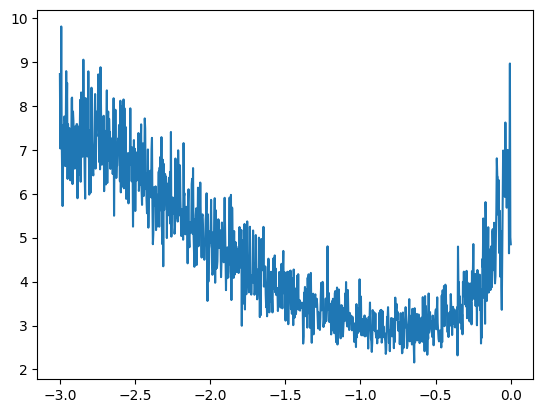

In [296]:
plt.plot(lri, lossi)

In [57]:
logits.max(1)

torch.return_types.max(
values=tensor([11.9425, 17.0823, 16.3651, 22.2974, 18.6956, 11.9425, 17.6936, 19.0422,
        12.7749, 22.2524, 15.2693, 16.7475, 11.9425, 18.3762, 14.3977, 18.5413,
        11.9425, 17.1599, 14.4797, 22.3679, 13.8646, 17.5190, 17.3921, 17.5671,
        15.3053, 11.9425, 16.9394, 17.9549, 17.0353, 14.0320, 18.5973, 19.6269],
       grad_fn=<MaxBackward0>),
indices=tensor([ 1, 13, 13,  1,  0,  1, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  1, 19,
         1,  2,  5, 12, 12,  1,  0,  1, 15, 16,  8,  9,  1,  0]))

In [68]:
torch.randint(0, X.shape[0], (32,))

tensor([ 16995, 170902, 141605, 124617, 114629, 222078,  94250, 222293,  79950,
         15729,  18500, 135065, 127147, 161032,   7351, 199238, 200627, 172233,
         43632, 180019,  47338,  55444, 199402, 225535, 130689,  51510, 122967,
         46205, 219198,  79147,  80518, 109232])

In [307]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
logits = h @ w2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1775, grad_fn=<NllLossBackward0>)

In [329]:
Xtr.shape, Ytr.shape

(torch.Size([182580, 3]), torch.Size([182580]))

In [ ]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g, requires_grad=True)
w1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
w2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, w1, b1, w2, b2]

In [343]:
sum(p.nelement() for p in parameters)

10281

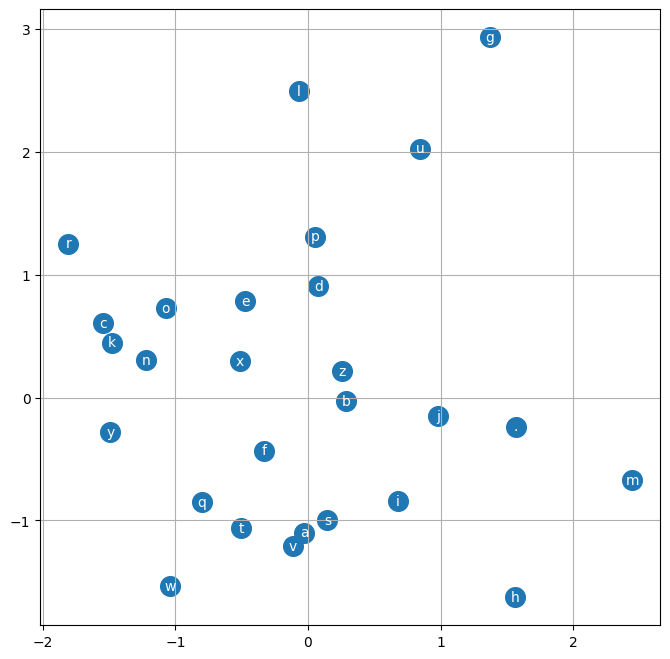

In [344]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [345]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 2])

In [346]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ w1 + b1)
      logits = h @ w2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

ssspasspasspasspasspasspasspastpewqbewszewqbewqbewszeaszepwqbewqbewszeaszeaszepwqbewszeaszeaszepwqbewqbewqbewszepwqbewqbewszepwqbewszeaszeaszepwqbewszepwqbewszeaszepwqbewszepwqbewszeaszepwqbewqbewszeaszeaszeaszeaszeaszeaszepwqbewszlwqbewqbewqbewszepwqbewqbewszepwqbewszepwqbewqbewszlwqbewqbewqbewszlwqbewszeaszepwqbewszepwqbewszlwqbewszeaszeaszepwqbewszepwqbewqbewqbewszepwqbewqbewszepwqbewqbewszlwqbewszeaszeaszeaszeaszepwqbewqbewqbewszewqbewqbewszepwqbewszeasspastpefitlvlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwl